In [3]:
# Step 1: LIME on Autoencoder modelv-> import libraries

# Autoencoder model work process: 
# Input:   80 features
# Encoder: 80 -> 64 neurons -> 32 neurons (compressed)
# Decoder: 32 -> 64 neurons -> 80 features (reconstructed)
# MSE: measures difference between input and reconstructed output
#      Low MSE  = normal traffic = BENIGN 
#      High MSE = strange traffic = ATTACK 
# LIME explains: which features caused MSE to be HIGH or LOW

import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import lime
import lime.lime_tabular
import json
import time

print(f"TensorFlow: {tf.__version__}")
# print(f"LIME: {lime.__version__}")  LIME does no have this attibute
print("Libraries imported!")

TensorFlow: 2.16.2
Libraries imported!


In [8]:
# Step 2: Load data and autoencoder
# load X_train, X_test (80 features)
# load ae_model.keras(already trained)
# load feature names (80 real names)

save_path = "/Users/miuyanhong/Desktop/replication_studies/XAI_Feature_Selection/CICIDS-2017/processed/"

# Load data
X_train = np.load(save_path + "X_train.npy")
X_test = np.load(save_path + "X_test.npy")
y_test = pd.read_csv(save_path + "y_test.csv").squeeze()

# Load autoencoder
ae_model = tf.keras.models.load_model(save_path + "ae_model.keras")

# Load real feature names
feature_names = pd.read_csv(
    save_path + "feature_names.csv",
    header=None
)[0].tolist()

feature_names = [f.strip() for f in feature_names]

print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"Features: {len(feature_names)}")
print(f"First 3: {feature_names[:3]}")
print("Data loaded!")

X_train: (1979513, 80)
X_test: (848363, 80)
Features: 80
First 3: ['Source Port', 'Destination Port', 'Protocol']
Data loaded!


In [11]:
# Step 3: prepare LIME + prediction function
# Define prediction function
# Same as SHAP - reconstruction error per sample
# input: 80 features; output: MSE score (1 number per sample )
# LIME need ONE number output to explain

def ae_predict(X):
    X_reconstructed = ae_model.predict(X, verbose=0)
    mse = np.mean(np.square(X - X_reconstructed), axis=1) # mse= check how different copy from original 
    return mse
# Create LIME explainer
explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train,
    feature_names=feature_names,
    mode="regression", # MSE = continuous output
    random_state=42
)

print("LIME explainer created!")

# Test prediction function
test_output = ae_predict(X_test[:3])
print(f"Sample MSE values: {test_output}")

LIME explainer created!
Sample MSE values: [0.00453539 0.00544043 0.0093615 ]


In [17]:
# Step 4: Run SHAP KernilExplainer
# LIME askes : which features push MSE HIGH or LOW?
# tests 500 random bakground samples, calculates LIME value for each of 80 features takes ~ 36 second

# Find one BENIGN and one ATTACK sample
benign_idx = y_test[y_test == "BENIGN"].index[0]
attack_idx = y_test[y_test != "BENIGN"].index[0]

# Get position in array
benign_pos = y_test.index.get_loc(benign_idx)
attack_pos = y_test.index.get_loc(attack_idx)

print(f"BENIGN sample index: {benign_pos}")
print(f"ATTACK sample index: {attack_pos}")
print(f"Attack type: {y_test.iloc[attack_pos]}")

# Explain BENIGN instance
print("\nExplaining BENIGN instance...")
start = time.time()
exp_benign = explainer.explain_instance(
    X_test[benign_pos],
    ae_predict,
    num_features=10
)
benign_time = round(time.time() - start, 2)
print(f"BENIGN explanation done! ({benign_time}s)")

# Explain ATTACK instance
print("\nExplaining ATTACK instance...")
start = time.time()
exp_attack = explainer.explain_instance(
    X_test[attack_pos],
    ae_predict,
    num_features=10
)
attack_time = round(time.time() - start, 2)
print(f"ATTACK explanation done! ({attack_time}s)")

# results
# SHAP  = 36 seconds for 50 samples
# LIME  = ~1 second per sample 
# = important SE metric finding for paper!

BENIGN sample index: 0
ATTACK sample index: 6
Attack type: PortScan

Explaining BENIGN instance...
BENIGN explanation done! (1.03s)

Explaining ATTACK instance...
ATTACK explanation done! (0.84s)


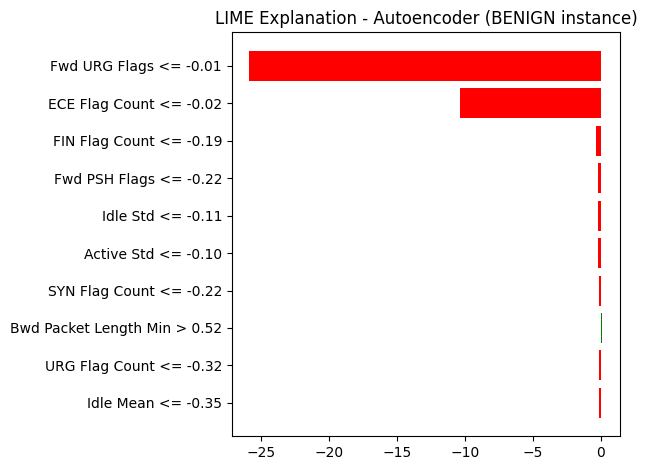

BENIGN plot saved!


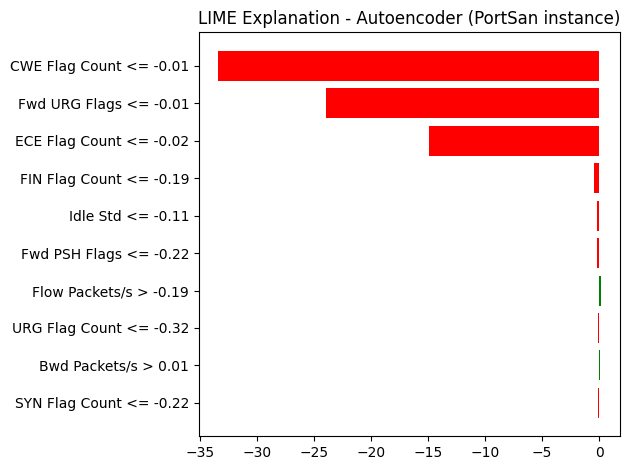

ATTACK plot saved!
Results saved!

Top 5 ATTACK features:
 CWE Flag Count <= -0.01: -33.397434
 Fwd URG Flags <= -0.01: -23.948187
 ECE Flag Count <= -0.02: -14.929854
 FIN Flag Count <= -0.19: -0.477168
 Idle Std <= -0.11: -0.214395


In [24]:
# Step 5: Get real feature names
# replace feature_0, features_1...
# with real names like destination port, FIN Flag Count
# saves feature_names.csv for future use

# Plot BENIGN explanation
fig_benign = exp_benign.as_pyplot_figure()
plt.title("LIME Explanation - Autoencoder (BENIGN instance)")
plt.tight_layout()
plt.savefig(save_path + "lime_ae_benign.png", dpi=150, bbox_inches="tight")
plt.show()

print("BENIGN plot saved!")

# plot ATTACK explanation
fig_attack = exp_attack.as_pyplot_figure()
plt.title("LIME Explanation - Autoencoder (PortSan instance)")
plt.tight_layout()
plt.savefig(save_path + "lime_ae_attack.png", dpi=150, bbox_inches="tight")
plt.show()
print("ATTACK plot saved!")

# Save results to JSON
results = {
    "model": "Autoencoder",
    "xai_method": "LIME",
    "benign_explanation_time": benign_time,
    "attack_explanation_time": attack_time,
    "attack_type": "PortScan",
    "benign_top_features": exp_benign.as_list(),
    "attack_top_features": exp_attack.as_list()
}

with open(save_path + "lime_ae_results.json","w") as f: 
    json.dump(results, f, indent=2)

print("Results saved!")
print("\nTop 5 ATTACK features:")
for feat, weight in exp_attack.as_list()[:5]:
    print(f" {feat}: {weight:.6f}")

Running LIME on 50 samples for global summary...
Please wait ~1 minute...
Done! Time: 36.47s


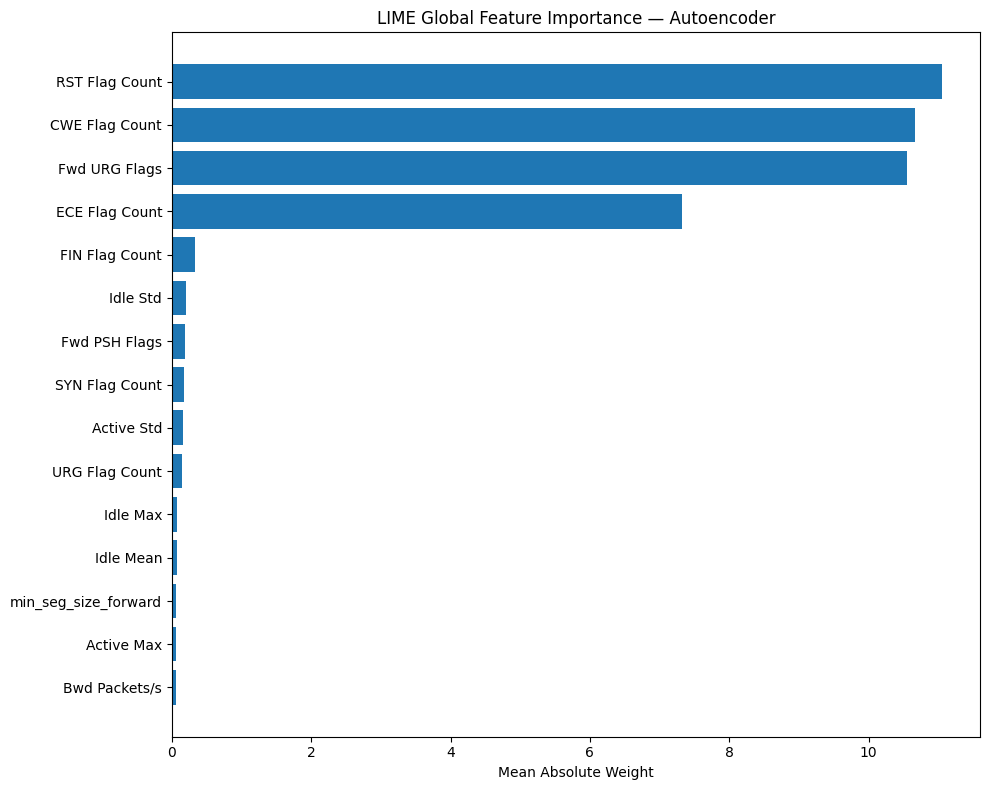

Global plot saved!


In [26]:
# Step 6: Replot with real feature names
# creates final LIME summary plot; save LIME_ae_global.png;
# save shap_ae_results.json; shows top 10 most import features


print("Running LIME on 50 samples for global summary...")
print("Please wait ~1 minute...")

np.random.seed(42)
sample_idx = np.random.choice(len(X_test), 50, replace=False)

# Collect all feature weights
all_weights = np.zeros((50, 80))

start = time.time()
for i, idx in enumerate(sample_idx):
    exp = explainer.explain_instance(
        X_test[idx],
        ae_predict,
        num_features=80
    )
    for feat, weight in exp.as_list():
        # match feature name to index
        for j, name in enumerate(feature_names):
            if name.strip() in feat:
                all_weights[i, j] = abs(weight)
                break

total_time = round(time.time() - start, 2)
print(f"Done! Time: {total_time}s")

# Plot global importance
mean_weights = all_weights.mean(axis=0)
top_idx = np.argsort(mean_weights)[::-1][:15]

plt.figure(figsize=(10, 8))
plt.barh(
    [feature_names[i].strip() for i in top_idx[::-1]],
    mean_weights[top_idx[::-1]]
)
plt.title("LIME Global Feature Importance — Autoencoder")
plt.xlabel("Mean Absolute Weight")
plt.tight_layout()
plt.savefig(save_path + "lime_ae_global.png", dpi=150, bbox_inches="tight")
plt.show()
print("Global plot saved!")

In [30]:
# Step 7: Save global LIME results to JSON

top_features_global = {
    feature_names[i].strip():round(float(mean_weights[i]),6)
    for i in top_idx
}

global_results = {
    "model": "Autoencoder",
    "xai_method": "LIME",
    "global_sample_size": 50,
    "total_time_seconds": total_time,
    "top_10_features": top_features_global
}

with open(save_path + "lime_ae_global_results.json", "w") as f:
    json.dump(global_results, f, indent=2)

print("Global results saved!")
print("\nTop 5 global features: ")
for i, idx in enumerate(top_idx[:5]):
    print(f" {i+1}. {feature_names[idx].strip()}: {mean_weights[idx]:.6f}")

Global results saved!

Top 5 global features: 
 1. RST Flag Count: 11.046479
 2. CWE Flag Count: 10.667515
 3. Fwd URG Flags: 10.545679
 4. ECE Flag Count: 7.322578
 5. FIN Flag Count: 0.335365
